# Bank filtration with TIMFlow

`gwtransport` represents an aquifer as an **aquifer pore volume distribution (APVD)**:
a list of pore volumes, one per parallel flow path ("streamtube"), each carrying an
equal share of the total flow. From the APVD plus an infiltration time series,
`gwtransport` computes residence times, extraction concentrations / temperatures, and
log-removals.

This notebook builds a steady-state analytic-element model of an alternating
canal / well-row bank-filtration strip using the TIMFlow PyPI package, traces the
equal-flux streamtubes, derives the discrete APVD, and feeds it into `gwtransport`
to produce a realistic multi-year temperature / residence-time / log-removal time
series. The TIMFlow model is 2D (vertical cross-section per unit length of well-row
into the page), so flow has units of m²/day and pore volumes units of m².

In [1]:
# This notebook needs the `timflow` PyPI package in addition to `gwtransport`.
# Install it once with `pip install timflow` (or `uv pip install timflow`).
import sys

try:
    import timflow.steady as tfs
except ImportError:
    print("timflow is not installed; install it with `pip install timflow`.")
    sys.exit(0)

import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Rectangle

from gwtransport.examples import generate_temperature_example_data
from gwtransport.logremoval import parallel_mean, residence_time_to_log_removal
from gwtransport.residence_time import residence_time_full
from gwtransport.utils import step_plot_coords

In [2]:
def build_strip_model(
    *,
    width,
    thickness,
    kaq,
    n_por,
    series_of_wells,
    z_well_top,
    z_well_bot,
    h_canal=0.0,
    canal_resistance=1.0,
    canal_width=1.0,
    naq=20,
    kzoverkh=1.0,
):
    """Build a single-aquifer cross-section model of one bank-filtration half-period.

    Covers ``[0, width] x [-thickness, 0]`` with a ``River1D`` canal at
    ``x = 0``, a partially penetrating ``LineSink1D`` well row at
    ``x = width``, and ``ImpermeableWall1D`` symmetry planes at both ends.

    Parameters
    ----------
    width, thickness : float
        Half-period width and aquifer thickness [m].
    kaq : float
        Horizontal hydraulic conductivity [m/day].
    n_por : float
        Effective porosity [-].
    series_of_wells : float
        Total well-row extraction per unit length of row [m²/day].
    z_well_top, z_well_bot : float
        Top and bottom elevation of the well screen [m].
    h_canal : float, optional
        Canal reference head [m].
    canal_resistance : float, optional
        Canal-bed resistance [day].
    canal_width : float, optional
        Canal bed width [m].
    naq : int, optional
        Number of equal vertical sublayers.
    kzoverkh : float, optional
        Vertical-to-horizontal conductivity ratio [-].

    Returns
    -------
    ml : timflow.steady.Model3D
        Solved model.

    Raises
    ------
    ValueError
        If ``z_well_bot`` is not strictly below ``z_well_top``, or if no
        sublayer centre lies within the well screen.
    """
    if z_well_bot >= z_well_top:
        msg = "z_well_bot must be strictly below z_well_top"
        raise ValueError(msg)

    z = np.linspace(0.0, -thickness, naq + 1)
    z_mid = 0.5 * (z[:-1] + z[1:])
    well_layers = np.where((z_mid >= z_well_bot) & (z_mid <= z_well_top))[0]
    if well_layers.size == 0:
        msg = f"No sublayer centre lies within the well screen [{z_well_bot}, {z_well_top}]."
        raise ValueError(msg)
    all_layers = list(range(naq))

    # Tiny inward offset so canal/well do not sit exactly on the symmetry walls.
    offset = 1e-3

    ml = tfs.Model3D(kaq=kaq, z=z, kzoverkh=kzoverkh, npor=n_por, topboundary="conf")
    tfs.River1D(model=ml, xls=offset, hls=h_canal, res=canal_resistance, wh=canal_width, layers=0)
    tfs.LineSink1D(model=ml, xls=width - offset, sigls=series_of_wells / 2.0, layers=well_layers.tolist())
    tfs.ImpermeableWall1D(model=ml, xld=0, layers=all_layers)
    tfs.ImpermeableWall1D(model=ml, xld=width, layers=all_layers)
    ml.solve(silent=True)
    return ml


def locate_streamlines_equal_flux(*, ml, n_start_locs, x_start_loc):
    """Return z-positions on ``x = x_start_loc`` that split flow into equal tubes."""
    qx, _ = ml.disvecalongline(x=[x_start_loc], y=[0.0], layers=None)
    z = np.asarray(ml.aq.find_aquifer_data(x=x_start_loc, y=0.0).z, dtype=float)
    cum = np.pad(np.cumsum(qx[::-1, 0]), (1, 0))
    targets = np.linspace(0.0, cum[-1], n_start_locs + 2)[1:-1]
    return np.interp(targets, cum, z[::-1])


def trace_tubes_bidirectional(*, ml, z_start_locs, x_start_loc, hstepmax=0.5, tmax=1e6, nstepmax=20000, win=None):
    """Trace each start location upstream and downstream and stitch into one pathline."""
    hstepmax = abs(hstepmax)
    z_start_locs = np.asarray(z_start_locs, dtype=float)
    xstart = np.full_like(z_start_locs, x_start_loc)
    ystart = np.zeros_like(z_start_locs)
    common = {"tmax": tmax, "nstepmax": nstepmax, "win": win, "silent": True, "metadata": True}
    back_list = tfs.timtracelines(ml, xstart, ystart, z_start_locs, -hstepmax, **common)
    fwd_list = tfs.timtracelines(ml, xstart, ystart, z_start_locs, hstepmax, **common)

    traces = []
    for back, fwd in zip(back_list, fwd_list, strict=True):
        xyzt_back = back["trace"]
        xyzt_fwd = fwd["trace"]
        tau_back = xyzt_back[-1, 3]
        tau_fwd = xyzt_fwd[-1, 3]

        xyzt_back_rev = xyzt_back[::-1].copy()
        xyzt_back_rev[:, 3] = tau_back - xyzt_back_rev[:, 3]
        xyzt_fwd_shift = xyzt_fwd[1:].copy()
        xyzt_fwd_shift[:, 3] += tau_back

        traces.append({
            "trace": np.vstack([xyzt_back_rev, xyzt_fwd_shift]),
            "message": f"back: {back['message']} | fwd: {fwd['message']}",
            "complete": bool(back["complete"] and fwd["complete"]),
            "tau_back": float(tau_back),
            "tau_fwd": float(tau_fwd),
        })
    return traces


def boundary_edge_trace(*, z_const, x_start, x_end, n_points=100):
    """Return a horizontal streamline trace along a no-flow domain boundary."""
    xs = np.linspace(float(x_start), float(x_end), int(n_points))
    xyzt = np.column_stack([xs, np.zeros_like(xs), np.full_like(xs, float(z_const)), np.zeros_like(xs)])
    return {"trace": xyzt, "message": "no-flow domain boundary", "complete": True}


def trace_streamtube_edges(*, ml, n_tubes, x_start_loc, width, thickness, **trace_kwargs):
    """Return ``n_tubes + 1`` edge traces, ordered from the aquifer floor upwards."""
    defaults = {"hstepmax": 0.5, "tmax": 1e6, "nstepmax": 20000}
    defaults.update(trace_kwargs)
    win = [0.0, width, -0.5, 0.5]
    z_start_locs = locate_streamlines_equal_flux(ml=ml, n_start_locs=n_tubes - 1, x_start_loc=x_start_loc)
    return [
        boundary_edge_trace(z_const=-thickness, x_start=0.0, x_end=width),
        *trace_tubes_bidirectional(ml=ml, z_start_locs=z_start_locs, x_start_loc=x_start_loc, win=win, **defaults),
        boundary_edge_trace(z_const=0.0, x_start=0.0, x_end=width),
    ]


def apvd_from_traces(*, traces_edges, porosity):
    """Return pore volume per streamtube from the shoelace area of edge traces."""
    n_tubes = len(traces_edges) - 1
    pore_vol = np.empty(n_tubes)
    for i in range(n_tubes):
        lower = traces_edges[i]["trace"]
        upper = traces_edges[i + 1]["trace"]
        x = np.concatenate([lower[:, 0], upper[::-1, 0]])
        z = np.concatenate([lower[:, 2], upper[::-1, 2]])
        area = 0.5 * abs(np.sum(x * np.roll(z, -1) - np.roll(x, -1) * z))
        pore_vol[i] = porosity * area
    return pore_vol


def plot_traced_streamlines(*, ax, traces, **kwargs):
    """Draw traced streamlines on ``ax`` and return the line artists."""
    defaults = {"color": "steelblue", "lw": 0.6, "alpha": 0.7}
    defaults.update(kwargs)
    lines = []
    for tr in traces:
        xy = tr["trace"]
        (line,) = ax.plot(xy[:, 0], xy[:, 2], **defaults)
        lines.append(line)
    return lines


def plot_traced_streamtubes(*, ax, traces, shade_colors=("lightgrey", "white"), line_kwargs=None, fontsize=7):
    """Shade streamtubes between consecutive edge traces and number each tube."""
    n_tubes = len(traces) - 1
    artists = []
    for i in range(n_tubes):
        lower = traces[i]["trace"][:, [0, 2]]
        upper = traces[i + 1]["trace"][:, [0, 2]]
        verts = np.vstack([lower, upper[::-1]])
        color = shade_colors[i % len(shade_colors)]
        poly = Polygon(verts, closed=True, facecolor=color, edgecolor="none", zorder=0)
        ax.add_patch(poly)
        artists.append(poly)

    defaults = {"color": "k", "lw": 0.5, "alpha": 0.6}
    if line_kwargs:
        defaults.update(line_kwargs)
    artists.extend(plot_traced_streamlines(ax=ax, traces=traces, **defaults))

    x_min = min(tr["trace"][:, 0].min() for tr in traces)
    x_max = max(tr["trace"][:, 0].max() for tr in traces)
    x_mid = 0.5 * (x_min + x_max)
    dx = 0.01 * (x_max - x_min)
    z_at_mid = [np.interp(x_mid, tr["trace"][:, 0], tr["trace"][:, 2]) for tr in traces]
    for i in range(n_tubes):
        x_lbl = x_mid - dx if i % 2 == 0 else x_mid + dx
        artists.append(
            ax.text(
                x_lbl,
                0.5 * (z_at_mid[i] + z_at_mid[i + 1]),
                str(i),
                ha="center",
                va="center",
                fontsize=fontsize,
                zorder=10,
            )
        )
    return artists


def plot_domain(
    *,
    ax,
    width,
    thickness,
    canal_width=None,
    canal_depth=2.0,
    h_canal=0.0,
    z_well_top=None,
    z_well_bot=None,
    well_x=None,
    well_casing_width=None,
):
    """Draw a conceptual bank-filtration cross-section without grass decoration."""
    artists = []

    rect_x = [0, width, width, 0, 0]
    rect_y = [-thickness, -thickness, 0, 0, -thickness]
    (line,) = ax.plot(rect_x, rect_y, "k-", lw=1.2)
    artists.append(line)

    (m1,) = ax.plot([0, 0], [-thickness, 0], "k--", lw=0.8, alpha=0.5)
    (m2,) = ax.plot([width, width], [-thickness, 0], "k--", lw=0.8, alpha=0.5)
    artists.extend([m1, m2])

    if canal_width is not None:
        canal_half = canal_width / 2.0
        water_top = h_canal
        water_bottom = max(-canal_depth, -thickness)
        water = Rectangle(
            xy=(0.0, water_bottom),
            width=canal_half,
            height=water_top - water_bottom,
            facecolor="#4a90d9",
            edgecolor="#1d4f8a",
            linewidth=1.2,
            alpha=0.55,
            zorder=90,
        )
        ax.add_patch(water)
        artists.append(water)
        (surface,) = ax.plot([0.0, canal_half], [water_top, water_top], color="#1d4f8a", lw=1.5, zorder=91)
        artists.append(surface)

    if z_well_top is not None and z_well_bot is not None:
        xw = float(well_x) if well_x is not None else width
        casing_w = well_casing_width if well_casing_width is not None else 0.02 * width
        casing_top = 0.05 * thickness
        casing = Rectangle(
            xy=(xw - casing_w / 2.0, -thickness),
            width=casing_w,
            height=casing_top - (-thickness),
            facecolor="#b0b0b0",
            edgecolor="black",
            linewidth=1.0,
            zorder=95,
            alpha=0.9,
        )
        ax.add_patch(casing)
        artists.append(casing)

        screen = Rectangle(
            xy=(xw - casing_w / 2.0, z_well_bot),
            width=casing_w,
            height=z_well_top - z_well_bot,
            facecolor="#d94a4a",
            edgecolor="#6b1d1d",
            linewidth=0.8,
            zorder=96,
            alpha=0.4,
        )
        ax.add_patch(screen)
        artists.append(screen)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("z [m]")
    ax.set_xlim(-0.02 * width, 1.02 * width)
    ax.set_ylim(-1.05 * thickness, 0.25 * thickness)
    return artists

In [3]:
# Geometry and aquifer properties
width, thickness = 70.0, 25.0  # m
kaq, n_por = 10.0, 0.35  # m/day, -
series_of_wells = 0.01  # m2/day per unit well-row length
z_well_top, z_well_bot = -10.0, -16.0  # m
canal_width, canal_depth = 5.0, 2.0  # m
naq = n_tubes = 25

ml = build_strip_model(
    width=width,
    thickness=thickness,
    kaq=kaq,
    n_por=n_por,
    series_of_wells=series_of_wells,
    z_well_top=z_well_top,
    z_well_bot=z_well_bot,
    canal_width=canal_width,
)

In [4]:
# Place tube boundaries at equal-flux intervals on the mid-domain line,
# then trace each one both upstream and downstream.
x_start_loc = width / 2
traces_edges = trace_streamtube_edges(
    ml=ml,
    n_tubes=n_tubes,
    x_start_loc=x_start_loc,
    width=width,
    thickness=thickness,
)

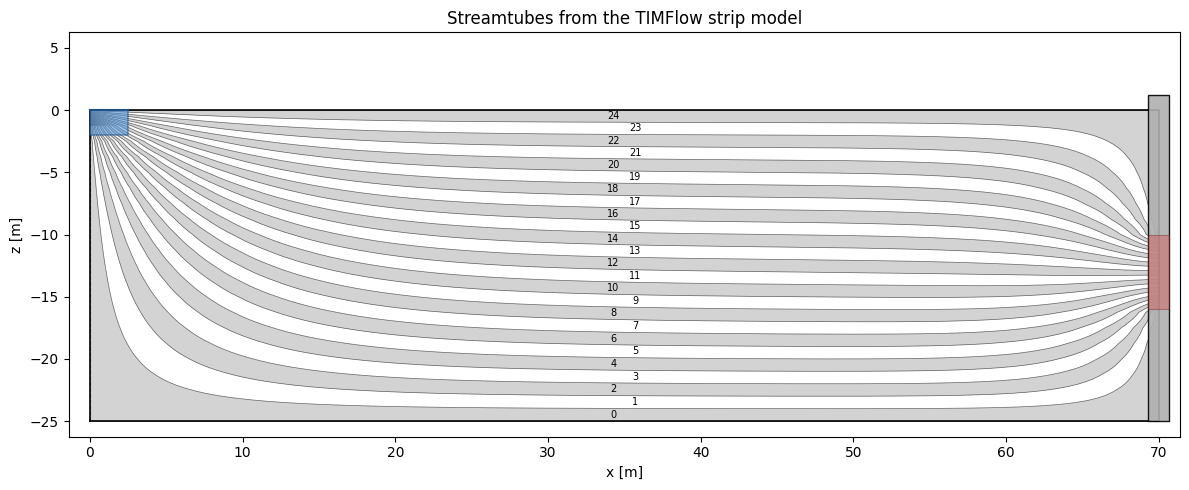

In [5]:
# Streamtubes shaded in alternating light grey / white, with tube indices
# matching the bar-chart ordering (tube 0 at the aquifer floor).
fig, ax = plt.subplots(figsize=(12, 5))
plot_traced_streamtubes(ax=ax, traces=traces_edges)
plot_domain(
    ax=ax,
    width=width,
    thickness=thickness,
    canal_width=canal_width,
    canal_depth=canal_depth,
    z_well_top=z_well_top,
    z_well_bot=z_well_bot,
)
ax.set_title("Streamtubes from the TIMFlow strip model")
plt.tight_layout()

## From streamtubes to APVD

Each streamtube has a physical pore volume $V_\mathrm{phys} = \text{porosity} \times
\text{streamtube area}$. The tubes are placed at equal flux, so every tube carries
$1/n_\mathrm{tubes}$ of the total flow and has probability mass $1/n_\mathrm{tubes}$
in the distribution.

`gwtransport` consumes the **full-flow-equivalent** pore volume
$V = n_\mathrm{tubes} \cdot V_\mathrm{phys}$: the pore volume a homogeneous aquifer
would need to reproduce this streamtube's residence time if it carried the entire
flow ($\tau = V / Q_\mathrm{total}$). Consequences:

- The list of $V$ values (one per tube) *is* the APVD that goes into `gwtransport`.
- **`mean(apvd) = V_tot`** (total aquifer pore volume); individual $V_i$ can exceed
  $V_\mathrm{tot}$ for slow streamtubes and be below it for fast ones.
- This matches what `gwtransport.gamma.bins(...)["expected_values"]` returns for a
  gamma-parameterised APVD.

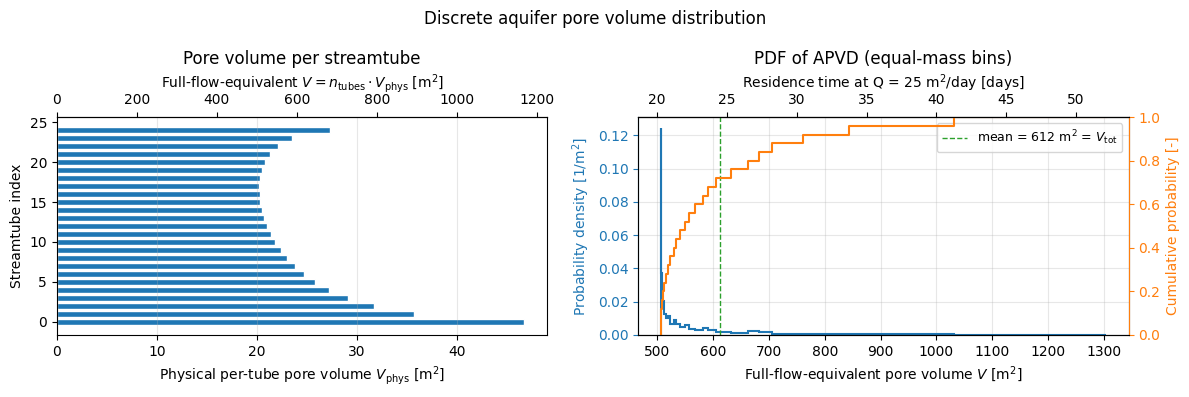

In [6]:
# Discrete APVD as consumed by gwtransport: each equal-flux streamtube is assigned its
# full-flow-equivalent pore volume V_i = tau_i * Q_total = n_tubes * porosity * area_i.
# This matches the convention of `gwtransport.gamma.bins(...)["expected_values"]` (equal
# probability mass 1/n per support point; mean over tubes equals total aquifer pore volume).
apvd = n_tubes * apvd_from_traces(traces_edges=traces_edges, porosity=n_por)

# Mean flow used further below as the residence-time scale on the PDF secondary
# x-axis; also consumed by `generate_temperature_example_data` in the dataset cell.
flow_mean = 25.0  # m^2/day

# Equal-mass bin edges: each equal-flux streamtube is its own bin, with edges at the
# midpoints between sorted support points (outer edges extrapolated symmetrically).
# Every bin carries probability mass 1/n_tubes, matching gwtransport.gamma.bins's
# `probability_mass = 1/n_bins` convention. Bin widths vary, so density =
# (1/n_tubes) / width_i is high where the support is dense and low where it is
# sparse; the integral over all bins is 1 by construction, and the distribution
# mean equals V_tot = total aquifer pore volume.
apvd_sorted = np.sort(apvd)
mids = 0.5 * (apvd_sorted[:-1] + apvd_sorted[1:])
bin_edges = np.concatenate([
    [2 * apvd_sorted[0] - mids[0]],
    mids,
    [2 * apvd_sorted[-1] - mids[-1]],
])

fig, (ax_bar, ax_pdf) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Discrete aquifer pore volume distribution")

# Left: physical per-tube pore volume. Secondary x-axis shows V = n_tubes * V_phys,
# i.e. the full-flow-equivalent value that is fed into gwtransport as
# `aquifer_pore_volumes`.
ax_bar.barh(range(n_tubes), apvd / n_tubes, height=0.8, edgecolor="white")
ax_bar.set_ylabel("Streamtube index")
ax_bar.set_xlabel(r"Physical per-tube pore volume $V_\mathrm{phys}$ [m$^2$]")
ax_bar.set_title("Pore volume per streamtube")
ax_bar.grid(True, alpha=0.3, axis="x")
secax_bar = ax_bar.secondary_xaxis("top", functions=(lambda v: v * n_tubes, lambda a: a / n_tubes))
secax_bar.set_xlabel(r"Full-flow-equivalent $V = n_\mathrm{tubes} \cdot V_\mathrm{phys}$ [m$^2$]")

# Right: stepped PDF (C0, primary axes) plus empirical CDF on a secondary y-axis
# (C1). Residence time at the mean flow is shown on a secondary x-axis (black).
ax_pdf.hist(apvd, bins=bin_edges, density=True, histtype="step", color="C0", lw=1.5)
ax_pdf.axvline(
    apvd.mean(),
    color="C2",
    ls="--",
    lw=1.0,
    label=rf"mean = {apvd.mean():.0f} m$^2$ = $V_\mathrm{{tot}}$",
)
ax_pdf.set_xlabel(r"Full-flow-equivalent pore volume $V$ [m$^2$]")
ax_pdf.set_ylabel("Probability density [1/m$^2$]", color="C0")
ax_pdf.tick_params(axis="y", colors="C0")
ax_pdf.spines["left"].set_color("C0")
ax_pdf.set_title("PDF of APVD (equal-mass bins)")
ax_pdf.grid(True, alpha=0.3)
ax_pdf.legend(loc="upper right", fontsize=9)

# Secondary y-axis: empirical CDF, stepped at the same bin edges as the PDF so the
# two are visually aligned. Within bin i, F = (i+1)/n_tubes (= cumulative histogram
# mass up to and including that bin).
ax_cdf = ax_pdf.twinx()
ax_cdf.step(
    bin_edges,
    np.linspace(0.0, 1.0, n_tubes + 1),
    where="pre",
    color="C1",
    lw=1.5,
)
ax_cdf.set_ylabel("Cumulative probability [-]", color="C1")
ax_cdf.set_ylim(0, 1)
ax_cdf.tick_params(axis="y", colors="C1")
ax_cdf.spines["right"].set_color("C1")

# Secondary x-axis: residence time at the mean flow, tau = V / flow_mean (default black).
secax_pdf = ax_pdf.secondary_xaxis("top", functions=(lambda v: v / flow_mean, lambda t: t * flow_mean))
secax_pdf.set_xlabel(f"Residence time at Q = {flow_mean:g} m$^2$/day [days]")

plt.tight_layout()

## Realistic multi-year dataset

Feed the streamline-derived discrete APVD into
`generate_temperature_example_data` to obtain a physically consistent dataset:
seasonal flow, KNMI-station soil temperature as the infiltration signal, and
modelled well-side temperature with thermal retardation (heat travels slower than
water because it partitions into the solid matrix) and longitudinal dispersion.

The resulting time series feeds the three-panel figure below:

1. **Temperature + flow** — infiltration and modelled extraction temperature.
2. **Median residence time** — water vs. heat, the latter longer due to thermal
   retardation.
3. **Log-removal** — two-component pathogen removal model for MS2 (a bacteriophage
   used as a virus surrogate): temperature-dependent inactivation plus a constant
   attachment term. Drinking-water guidelines typically target 8 log$_{10}$
   removal for viruses in bank filtration.

In [7]:
df, tedges_ts = generate_temperature_example_data(
    date_start="2020-01-01",
    date_end="2024-12-31",
    flow_mean=flow_mean,
    flow_amplitude=12.5,
    flow_noise=0.25,
    cin_method="soil_temperature",
    aquifer_pore_volumes=apvd,
    measurement_noise=0.1,
    streamline_length=width,
)

# Mean residence times per tube over each output interval
rt_water = residence_time_full(
    flow=df.flow,
    tedges=tedges_ts,
    cout_tedges=tedges_ts,
    aquifer_pore_volumes=apvd,
    retardation_factor=1.0,
    direction="extraction_to_infiltration",
)
rt_thermal = residence_time_full(
    flow=df.flow,
    tedges=tedges_ts,
    cout_tedges=tedges_ts,
    aquifer_pore_volumes=apvd,
    retardation_factor=df.attrs["retardation_factor"],
    direction="extraction_to_infiltration",
)

# All-NaN slices at the series edges are expected; silence the warning.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)
    df["rt_water_median"] = np.nanmedian(rt_water, axis=0)
    df["rt_thermal_median"] = np.nanmedian(rt_thermal, axis=0)

# Two-component log-removal: MS2 inactivation at 10 degC plus constant attachment.
log10_decay_rate = np.exp(0.12 * 10 - 3.5) / np.log(10)
lr_attachment = 7.0
log_removal_decay = residence_time_to_log_removal(
    residence_times=rt_water,
    log10_decay_rate=log10_decay_rate,
)
df["lr_decay"] = parallel_mean(log_removals=log_removal_decay, axis=0)
df["lr_total"] = df["lr_decay"] + lr_attachment

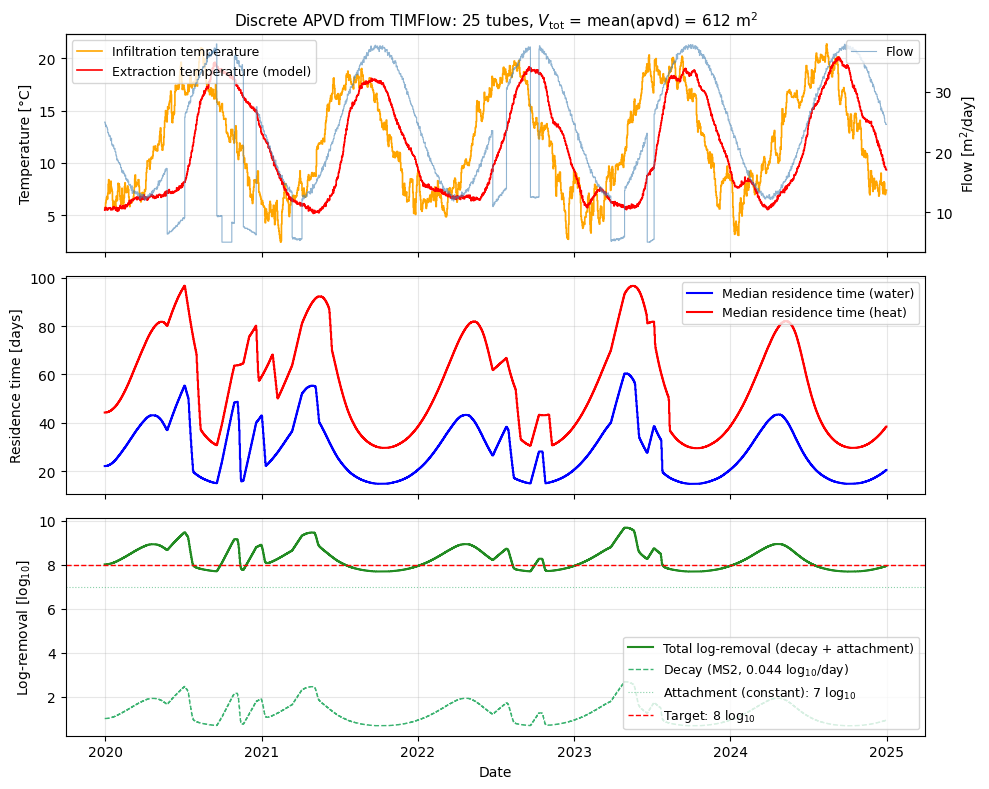

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Top panel: infiltration / extraction temperature + flow on a twin axis ---
ax1.plot(*step_plot_coords(tedges_ts, df.cin), color="orange", lw=1.2, label="Infiltration temperature")
ax1.plot(*step_plot_coords(tedges_ts, df.cout), color="red", lw=1.2, label="Extraction temperature (model)")
ax1.set_ylabel("Temperature [°C]")
ax1.legend(loc="upper left", fontsize=9)

ax1b = ax1.twinx()
ax1b.plot(*step_plot_coords(tedges_ts, df.flow), color="steelblue", lw=0.8, alpha=0.6, label="Flow")
ax1b.set_ylabel("Flow [m$^2$/day]")
ax1b.legend(loc="upper right", fontsize=9)

ax1.set_title(
    f"Discrete APVD from TIMFlow: {n_tubes} tubes, "
    rf"$V_\mathrm{{tot}}$ = mean(apvd) = {apvd.mean():.0f} m$^2$",
    fontsize=11,
)

# --- Middle panel: median residence time (water and thermal) ---
ax2.plot(
    *step_plot_coords(tedges_ts, df.rt_water_median),
    color="blue",
    lw=1.5,
    label="Median residence time (water)",
)
ax2.plot(
    *step_plot_coords(tedges_ts, df.rt_thermal_median),
    color="red",
    lw=1.5,
    label="Median residence time (heat)",
)
ax2.set_ylabel("Residence time [days]")
ax2.legend(loc="upper right", fontsize=9)

# --- Bottom panel: log-removal (decay + attachment) ---
ax3.plot(
    *step_plot_coords(tedges_ts, df.lr_total),
    color="forestgreen",
    lw=1.5,
    label="Total log-removal (decay + attachment)",
)
ax3.plot(
    *step_plot_coords(tedges_ts, df.lr_decay),
    color="mediumseagreen",
    lw=1.0,
    ls="--",
    label=f"Decay (MS2, {log10_decay_rate:.3f} log$_{{10}}$/day)",
)
ax3.axhline(
    y=lr_attachment,
    color="mediumseagreen",
    ls=":",
    lw=0.8,
    alpha=0.6,
    label=f"Attachment (constant): {lr_attachment:.0f} log$_{{10}}$",
)
ax3.axhline(y=8.0, color="red", ls="--", lw=1.0, label="Target: 8 log$_{10}$")
ax3.set_ylabel("Log-removal [log$_{10}$]")
ax3.set_xlabel("Date")
ax3.legend(loc="lower right", fontsize=9)

for ax in (ax1, ax2, ax3):
    ax.grid(True, alpha=0.3)

plt.tight_layout()